# Rede Neural

Imports

In [8]:
from src.objetos import Dados, camada_densa, rede_neural

Caminho contendo os dados das imagens e os rótulos correspondentes.

In [9]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

Inicialização dos dados

In [10]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

Método de separação dos dados

In [11]:
dados._holdout(0.6, 0.2)

Parâmetros da rede neural

In [12]:
epocas = 500
taxa_aprendizado = 1
lambda_reg = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]

Inicialização das camadas e rede neural e treino com diferentes lambdas

In [13]:
import pandas as pd
import os
import numpy as np

os.makedirs("logs", exist_ok=True)

custos_validacao = []

for lambda_i in lambda_reg:
    camadas = []

    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
        # Aplica softmax na ultima camada
        camada = camada_densa.CamadaDensa(
                tamanho_entrada=arquitetura_camadas[-2], 
                tamanho_saida=arquitetura_camadas[-1],
                funcao_de_ativacao='softmax'
                )
        camadas.append(camada)

    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_i)

    rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_i
    )

    logs_atual = pd.read_csv("log_treinamento.csv")
    custo_valid = logs_atual['custo_validacao_sem_reg'].iloc[-1]

    custos_validacao.append(custo_valid)
    logs_atual.to_csv(f"logs/log_lambda_{lambda_i}.csv", index=False)

custo_otimo = np.min(custos_validacao)
lambda_otimo = lambda_reg[np.argmin(custos_validacao)]

df_lambda_otimo = pd.read_csv(f"logs/log_lambda_{lambda_otimo}.csv")
custo_treino_lambda_otimo = df_lambda_otimo['custo_treinamento'].iloc[-1]

print(lambda_otimo)

0.01


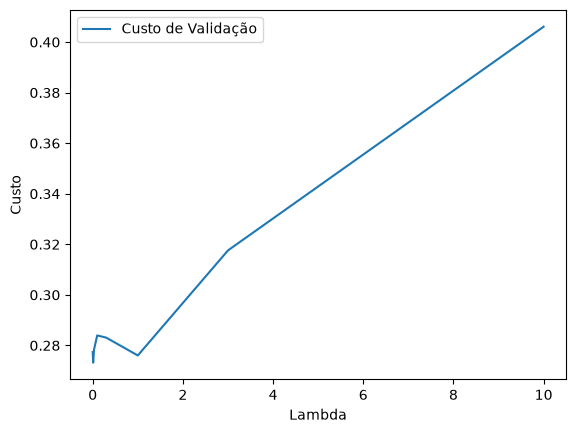

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(lambda_reg,custos_validacao, label="Custo de Validação")
plt.xlabel("Lambda")
plt.ylabel("Custo")
plt.legend()
plt.show()